In [3]:
!pip install transformers datasets evaluate accelerate -U -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 56.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import torch
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from google.colab import drive, runtime

import gc
import ast
from datasets import Dataset, load_dataset
from transformers.pipelines.pt_utils import KeyDataset
import nltk
from nltk.tokenize import sent_tokenize
import os

import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)



In [ ]:
# Installing the current versions of the Hugging Face ecosystem
!pip install transformers datasets evaluate accelerate -U -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 155.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 59.0 MB/s eta 0:00:00


In [ ]:

# !pip install transformers datasets evaluate accelerate -U -q

print(f"GPU Available: {torch.cuda.is_available()}")

GPU Available: True


### Acquire and prep labelled data


In [2]:
print("Downloading modern Parquet-native financial dataset...")

dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")

print("Dataset splits:")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sent_train.csv: 0.00B [00:00, ?B/s]

sent_valid.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/9543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2388 [00:00<?, ? examples/s]

Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})


### Tokenization

In [ ]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

print("Tokenizing the dataset...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets.set_format("torch")
print("Tokenization complete.")

### Model Init

In [ ]:
print(f"Loading base foundation model: {model_name}...")
# num_labels=3 matches  Negative, Neutral, Positive classes
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

### Train and save Custom Model

In [ ]:
drive.mount('/content/drive')

output_dir = '/content/drive/MyDrive/Colab Notebooks/custom_financial_bert'

print("Setting up training arguments...")
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

print("Starting Fine-Tuning")
trainer.train()

# Save the explicitly fine-tuned model and tokenizer to Google Drive
print(f"Saving custom model to: {output_dir}")
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print("Saved model")

## 4B

In [ ]:
# Enable progress bars for Pandas operations
tqdm.pandas()

# Download the sentence tokenizer
try:
    nltk.data.find('tokenizers/punkt')
    print("found punkt")
except LookupError:
    nltk.download('punkt')
    print("downloaded punkt")


nltk.download('punkt_tab')

## Load model and phase 3 data

In [3]:
drive.mount('/content/drive')

model_path = '/content/drive/MyDrive/Colab Notebooks/custom_financial_bert'
df_path = '/content/drive/MyDrive/Colab Notebooks/df_with_topics_and_entities.parquet'

print(f"Loading data from {df_path}...")
df = pd.read_parquet(df_path)

print(f"Loading custom model from {model_path}...")
# batch_size=32 pushes data to the GPU in chunks, speeding up inference by 10x
# truncation=True since news articles are "front-loaded"
sentiment_pipeline = pipeline(
    "text-classification",
    model=model_path,
    tokenizer=model_path,
    device=0,
    truncation=True,
    max_length=512,
    batch_size=64
)
print("Pipeline ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data from /content/drive/MyDrive/Colab Notebooks/df_with_topics_and_entities.parquet...
Loading custom model from /content/drive/MyDrive/Colab Notebooks/custom_financial_bert...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Pipeline ready.


Evaluating Fine-Tuned Model on UNSEEN Validation Set...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running predictions on 2388 validation samples...


  0%|          | 0/2388 [00:00<?, ?it/s]


--- Validation Classification Report ---
              precision    recall  f1-score   support

Negative (0)       0.79      0.83      0.81       347
Positive (1)       0.85      0.80      0.82       475
 Neutral (2)       0.92      0.92      0.92      1566

    accuracy                           0.89      2388
   macro avg       0.85      0.85      0.85      2388
weighted avg       0.89      0.89      0.89      2388



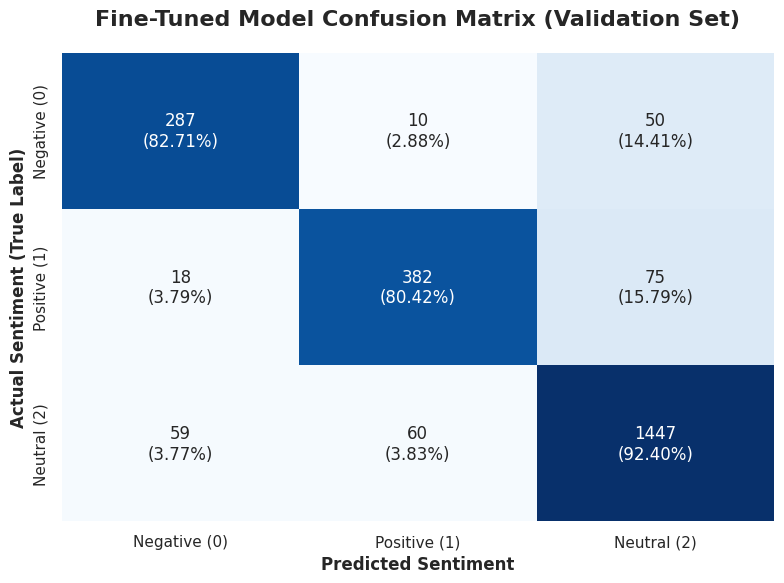

In [ ]:
# Set professional business theme for the plot
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False})

print("Evaluating Fine-Tuned Model on UNSEEN Validation Set...")

# 1. LOAD FINE-TUNED MODEL
eval_pipeline = pipeline("text-classification", model=model_path, device=0) # device=0 uses GPU

from tqdm.auto import tqdm

# 2. EXTRACT AND CLEAN THE VALIDATION SPLIT
val_data = dataset['validation']

texts = [str(t) for t in val_data['text']]
true_labels = val_data['label']

# 3. GENERATE PREDICTIONS
print(f"Running predictions on {len(texts)} validation samples...")

# Using tqdm to giveyou a progress bar
predictions = []
for out in tqdm(eval_pipeline(texts, batch_size=64, truncation=True, max_length=128), total=len(texts)):
    predictions.append(out)

# Extract the integer to match true_labels
predicted_labels = []
for p in predictions:
    label_str = p['label']
    if label_str.startswith('LABEL_'):
        predicted_labels.append(int(label_str.split('_')[-1]))
    else:
        label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
        predicted_labels.append(label_map.get(label_str, 0))

# 4. CALCULATE METRICS
print("\n--- Validation Classification Report ---")
# The target names map back to the original dataset (0: Bearish, 1: Bullish, 2: Neutral)
target_names = ['Negative (0)', 'Positive (1)', 'Neutral (2)']
print(classification_report(true_labels, predicted_labels, target_names=target_names))

# 5. BUILD THE CONFUSION MATRIX
cm = confusion_matrix(true_labels, predicted_labels)

# Normalize the matrix to get the percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

annot_labels = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # Formats like: "150\n(10.50%)"
        raw_val = int(cm[i, j])
        pct_val = float(cm_normalized[i, j])

        # Format: "150\n(10.50%)"
        annot_labels[i, j] = f"{raw_val}\n({pct_val:.2%})"
        # annot_labels[i, j] = f"{cm[i, j]}\n({cm_normalized[i, j]:.2}\%)"

# 6. PLOT IT
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=False
)

plt.title('Fine-Tuned Model Confusion Matrix (Validation Set)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Sentiment', fontsize=12, fontweight='bold')
plt.ylabel('Actual Sentiment (True Label)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Validation_Confusion_Matrix.png', dpi=300)
plt.show()

### Topic level inference

In [ ]:
# Map the raw Hugging Face labels to numeric impact scores
label_mapping = {"LABEL_0": -1, "LABEL_1": 1, "LABEL_2": 0}

print("Running Topic-Level Inference (Batch Mode)...")
# Convert text to a list for the pipeline
docs = df['cleaned_text_v2'].astype(str).tolist()

# Run the inference
results = sentiment_pipeline(docs)

# Map results back to the dataframe
df['article_sentiment_label'] = [res['label'] for res in results]
df['article_sentiment_score'] = df['article_sentiment_label'].map(label_mapping)

# Calculate Topic-Level Aggregation
topic_sentiment = df.groupby(['Topic_ID', 'Topic_Name'])['article_sentiment_score'].mean().reset_index()
topic_sentiment = topic_sentiment.sort_values('article_sentiment_score', ascending=False)

print("\nTop Topics by Sentiment (Most Positive to Most Negative):")
display(topic_sentiment.head(10))

In [ ]:

checkpoint_dir = '/content/drive/MyDrive/Colab Notebooks/nlp_checkpoints'
# os.makedirs(checkpoint_dir, exist_ok=True)

topic_checkpoint_path = os.path.join(checkpoint_dir, 'checkpoint_1_topic_inference.parquet')

# Save the updated main dataframe containing 'article_sentiment_score'
df.to_parquet(topic_checkpoint_path, index=False)

print(f"CHECKPOINT 1 SAVED: Topic-level inference secured at {topic_checkpoint_path}")

### Entity level inference

In [ ]:
dates = df['date'].tolist() if 'date' in df.columns else [None] * len(df)
texts = df['cleaned_text_v2'].tolist()
topics = df['Topic_ID'].tolist()
orgs_list = df['organizations'].tolist()

In [ ]:

print(" Pre-counting valid entities to save RAM...")
# Count entities first without duplicating any text data
entity_counts = {}
for orgs in df['organizations']:
    if isinstance(orgs, str):
        try: orgs = ast.literal_eval(orgs)
        except: continue
    elif isinstance(orgs, np.ndarray):
        orgs = orgs.tolist()

    if isinstance(orgs, list):
        for org in orgs:
            if org and not pd.isna(org):
                org_lower = str(org).lower()
                entity_counts[org_lower] = entity_counts.get(org_lower, 0) + 1

# Keep only companies mentioned 50+ times
valid_entities_lower = {k for k, v in entity_counts.items() if v >= 50}
print(f"Found {len(valid_entities_lower)} high-signal organizations.")

print("\nMemory-Efficient Extraction...")
col_article_id, col_topic_id, col_entity, col_sentence, col_date = [], [], [], [], []
for row in tqdm(df.itertuples(), total=len(df), desc="Extracting"):
    orgs = row.organizations
    if isinstance(orgs, str):
        try: orgs = ast.literal_eval(orgs)
        except: continue
    elif isinstance(orgs, np.ndarray):
        orgs = orgs.tolist()

    if not isinstance(orgs, list) or len(orgs) == 0:
        continue

    # Check for valid orgs BEFORE tokenizing
    valid_orgs_in_row = [org for org in orgs if org and not pd.isna(org) and str(org).lower() in valid_entities_lower]

    if not valid_orgs_in_row:
        continue

    text = str(row.cleaned_text_v2)
    sentences = sent_tokenize(text)

    for org in valid_orgs_in_row:
        org_str = str(org).lower()
        for sent in sentences:
            if org_str in sent.lower():
                col_article_id.append(row.Index)
                col_topic_id.append(row.Topic_ID)
                col_entity.append(org)
                col_sentence.append(sent)
                col_date.append(getattr(row, 'date', None))

# Create the filtered dataframe directly
df_entities = pd.DataFrame({
    "Article_ID": col_article_id,
    "Topic_ID": col_topic_id,
    "Entity": col_entity,
    "Sentence": col_sentence,
    "Date": col_date
})

print(f"\nExtracted {len(df_entities):,} highly relevant sentences.")

print("\nForcing Python Garbage Collection...")
# Explicitly delete the massive lists to free up Gigabytes of RAM for the GPU
del col_article_id, col_topic_id, col_entity, col_sentence, col_date
gc.collect()
print("RAM cleared. Ready for inference.")

In [ ]:


# 1. Map the raw integer predictions (0, 1, 2) directly to scoring system
# 0 (Negative) -> -1 | 1 (Positive) -> 1 | 2 (Neutral) -> 0
score_map = {0: -1, 1: 1, 2: 0}

print("Loading Native PyTorch Model in FP16 (Half-Precision)...")
# Force the model into float16 to activate the T4 GPU's Tensor Cores
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    torch_dtype=torch.float16
).cuda()

model.eval() # Set model to evaluation mode

# 2. Create a lightweight PyTorch Dataset
class SentenceDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return str(self.texts[idx])

print("Preparing DataLoader...")
dataset = SentenceDataset(df_entities['Sentence'].tolist())
# num_workers=2 utilizes Colab's CPU cores to feed the GPU faster
dataloader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)

entity_scores = []

print("Starting High-Speed PyTorch Inference...")
# inference_mode() is a newer, faster version of no_grad()
with torch.inference_mode():
    for batch in tqdm(dataloader, desc="Scoring Batches"):
        # MAX_LENGTH=128 stops the quadratic padding explosion on outlier sentences
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to("cuda")

        outputs = model(**inputs)

        # Grab the highest probability class
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()

        # Map predictions to -1, 0, 1 and store
        entity_scores.extend([score_map[p] for p in preds])

# 3. Apply to DataFrame and Aggregate
df_entities['sentiment_score'] = entity_scores

entity_sentiment = df_entities.groupby('Entity').agg(
    mention_count=('Entity', 'count'),
    avg_sentiment=('sentiment_score', 'mean')
).reset_index().sort_values('avg_sentiment', ascending=False)

print("\nTop 15 Organizations by Sentiment:")
display(entity_sentiment.head(15))

### Save results

In [ ]:
df_main_path = '/content/drive/MyDrive/Colab Notebooks/df_final_topic_sentiment.parquet'
df_entities_path = '/content/drive/MyDrive/Colab Notebooks/df_final_entity_sentiment.parquet'

df.to_parquet(df_main_path, index=False)
df_entities.to_parquet(df_entities_path, index=False)


In [ ]:
## LOAD THE PARQUETs

drive.mount('/content/drive')

df_main_path = '/content/drive/MyDrive/Colab Notebooks/df_final_topic_sentiment.parquet'
df_entities_path = '/content/drive/MyDrive/Colab Notebooks/df_final_entity_sentiment.parquet'

print(f"Loading data from {df_main_path}...")
df = pd.read_parquet(df_main_path)

print(f"Loading data from {df_entities_path}...")
df_entities = pd.read_parquet(df_entities_path)

topic_sentiment = df.groupby(['Topic_ID', 'Topic_Name'])['article_sentiment_score'].mean().reset_index()
topic_sentiment = topic_sentiment.sort_values('article_sentiment_score', ascending=False)

entity_counts = df_entities['Entity'].value_counts()
valid_entities = entity_counts[entity_counts >= 15].index

entity_sentiment = df_entities[df_entities['Entity'].isin(valid_entities)]
entity_sentiment = entity_sentiment.groupby('Entity').agg(
    mention_count=('Entity', 'count'),
    avg_sentiment=('sentiment_score', 'mean')
).reset_index().sort_values('avg_sentiment', ascending=False)



Mounted at /content/drive
Loading data from /content/drive/MyDrive/Colab Notebooks/df_final_topic_sentiment.parquet...
Loading data from /content/drive/MyDrive/Colab Notebooks/df_final_entity_sentiment.parquet...


### Basic Visualize for quick sanity check

/tmp/ipykernel_2208/1743415972.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2208/1743415972.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


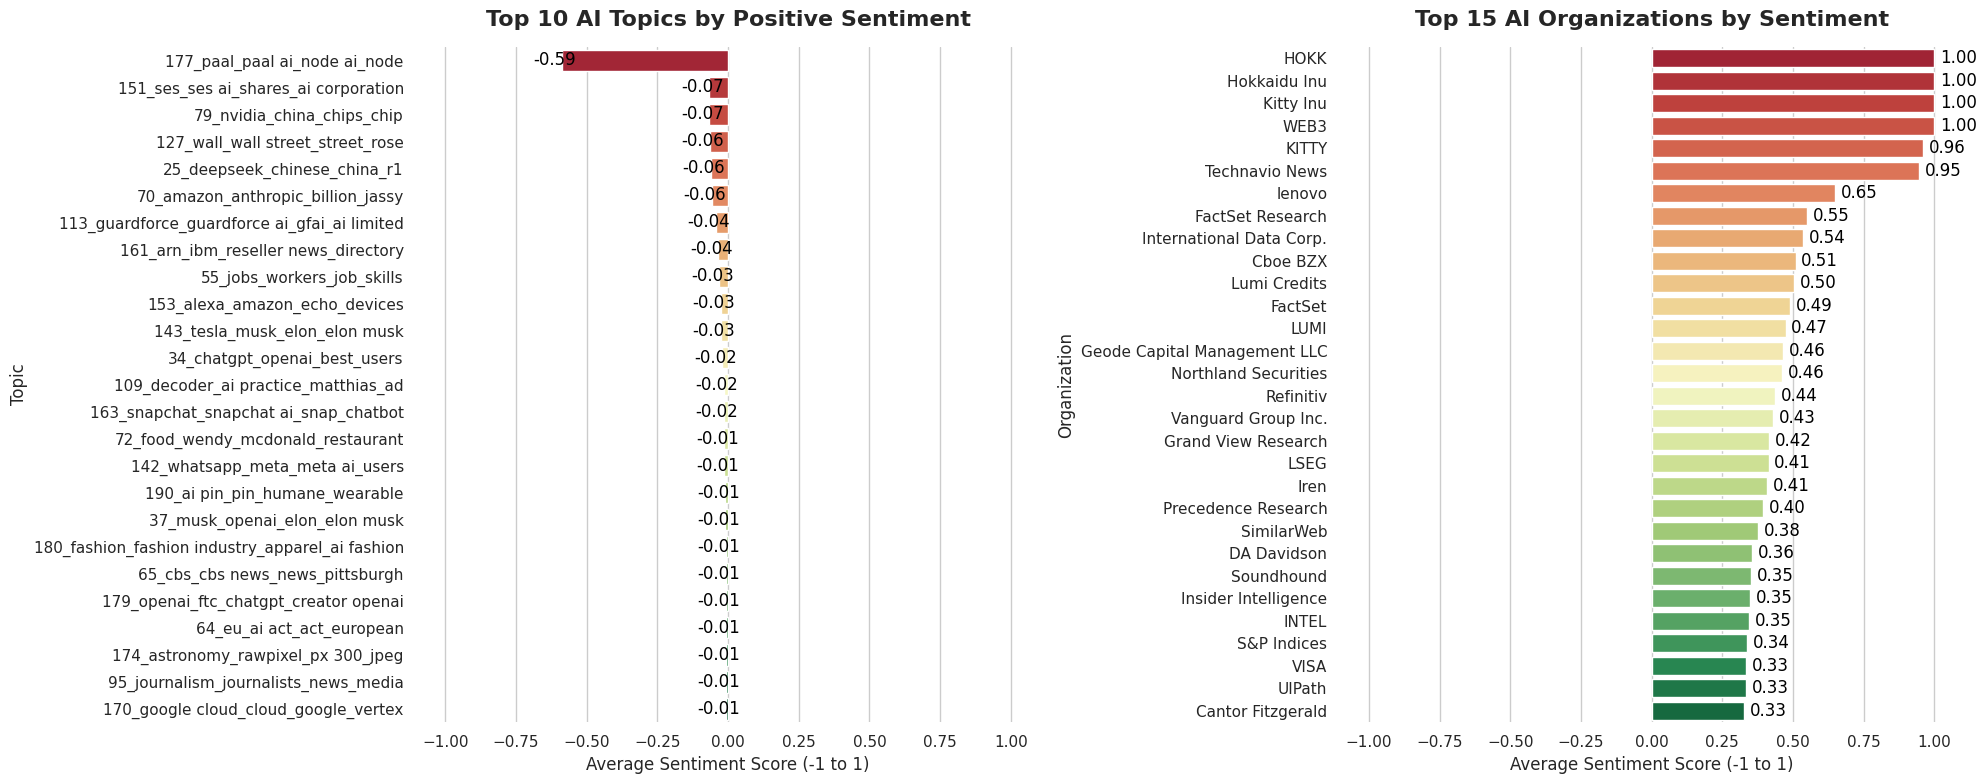

In [ ]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ==========================================
# PLOT 1: Top 10 Topics by Sentiment
# ==========================================
# Sort to get the most positive and most negative, or just top 10 most positive
top_topics = topic_sentiment.sort_values('article_sentiment_score', ascending=False).head(25)

sns.barplot(
    data=top_topics,
    x='article_sentiment_score',
    y='Topic_Name',
    ax=axes[0],
    palette="RdYlGn"
)
axes[0].set_title('Top 10 AI Topics by Positive Sentiment', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Average Sentiment Score (-1 to 1)', fontsize=12)
axes[0].set_ylabel('Topic', fontsize=12)
axes[0].set_xlim(-1.1, 1.1)

# Add data labels
for i, v in enumerate(top_topics['article_sentiment_score']):
    axes[0].text(v + 0.02 if v > 0 else v - 0.1, i, f"{v:.2f}", color='black', va='center')

# ==========================================
# PLOT 2: Top 15 Organizations by Sentiment
# ==========================================
# Get the top 15 most mentioned valid entities, sorted by sentiment
top_entities = entity_sentiment.sort_values('avg_sentiment', ascending=False).head(30)
sns.barplot(
    data=top_entities,
    x='avg_sentiment',
    y='Entity',
    ax=axes[1],
    palette="RdYlGn"
)
axes[1].set_title('Top 15 AI Organizations by Sentiment', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Average Sentiment Score (-1 to 1)', fontsize=12)
axes[1].set_ylabel('Organization', fontsize=12)
axes[1].set_xlim(-1.1, 1.1)

# Add data labels
for i, v in enumerate(top_entities['avg_sentiment']):
    axes[1].text(v + 0.02 if v > 0 else v - 0.1, i, f"{v:.2f}", color='black', va='center')

# Clean up layout and display
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save the quick validation plot
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Sentiment_validation_check.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

# Load  saved entity data
# df_entities = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/df_final_entity_sentiment.parquet')

def audit_entity(entity_name, df, num_samples=5):
    """
    Pulls the exact sentences that drove an entity's sentiment score,
    showing the most positive and most negative contexts.
    """
    # Filter the dataframe for the specific entity (case-insensitive)
    target_df = df[df['Entity'].astype(str).str.lower() == entity_name.lower()].copy()

    if len(target_df) == 0:
        print(f"No records found for entity: '{entity_name}'")
        return

    overall_score = target_df['sentiment_score'].mean()
    print(f"=== SENTIMENT AUDIT: {entity_name.upper()} ===")
    print(f"Total Mentions: {len(target_df)}")
    print(f"Overall Average Score: {overall_score:.3f} (-1 to 1)\n")

    # Grab the most POSITIVE sentences (Score = 1)
    positive_sentences = target_df[target_df['sentiment_score'] == 1]['Sentence'].head(num_samples)
    print("TOP POSITIVE CONTEXTS:")
    if len(positive_sentences) == 0:
        print("  (None found)")
    else:
        for i, sent in enumerate(positive_sentences, 1):
            print(f"  {i}. {sent.strip()}")

    print("\n" + "-"*50 + "\n")

    # Grab the most NEGATIVE sentences (Score = -1)
    negative_sentences = target_df[target_df['sentiment_score'] == -1]['Sentence'].head(num_samples)
    print("TOP NEGATIVE CONTEXTS:")
    if len(negative_sentences) == 0:
        print("  (None found)")
    else:
        for i, sent in enumerate(negative_sentences, 1):
            print(f"  {i}. {sent.strip()}")

company_check_for_audit = 'google'
audit_entity(company_check_for_audit, df_entities, num_samples=3)

#  Find the unique Topic_IDs associated with the entity company_check_for_audit
audit_company_topic_ids = df_entities[df_entities['Entity'].astype(str).str.lower() == company_check_for_audit]['Topic_ID'].unique()

# Look up the corresponding Topic Names from main dataframe
audit_company_topic_names = df[df['Topic_ID'].isin(audit_company_topic_ids)][['Topic_ID', 'Topic_Name']].drop_duplicates()

print(f"\n\n{company_check_for_audit} belongs to the following topics:")
display(audit_company_topic_names)

=== SENTIMENT AUDIT: GOOGLE ===
Total Mentions: 82274
Overall Average Score: 0.009 (-1 to 1)

TOP POSITIVE CONTEXTS:
  1. Research shows that product offers on Google with multiple images witness a significant boost in impressions (+76%) and clicks (+32%) compared to those with just one image.
  2. According to Google, the number of businesses utilizing Merchant Center has doubled over the past couple of years.
  3. In February, Microsoft launched Bing Chat, which runs on ChatGPT-4 technology.After a shaky start — with the accuracy of its findings being called into question — Bing Chat has been in heated competition with Google parent company Alphabet’s AI chatbot called Bard — and both bots are up against the original ChatGPT.Microsoft enjoyed a strong first quarter of the year, with its revenue increasing by 11% to $50.12 billion.

--------------------------------------------------

TOP NEGATIVE CONTEXTS:
  1. Given OpenAI's relationship with Microsoft, some investors feared that Goo

,Topic_ID,Topic_Name
0,3,11_price_prediction_price prediction_usd
1,-1,-1_ai_news_new_data
2,0,20_product_product hunt_hunt_tips
3,0,15_automotive_vehicles_vehicle_driving
5,0,33_bard_google_google bard_chatgpt
...,...,...
2930,2,103_italian_italy_chatgpt_openai
3966,0,188_nadella_satya_satya nadella_microsoft
4113,0,137_internet1_cookies_use cookies_telecom
4821,28,183_loved_loved ones_deceased_person


In [ ]:
print("All tasks complete and saved to Google Drive.")
print("Shutting down the Colab runtime to save compute credits...")

# This command forcefully unassigns the GPU and terminates the session
runtime.unassign()